/tmp/ipykernel_4717/3656472764.py:26: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period=period, group_by='column')
[*********************100%***********************]  1 of 1 completed

Récupération des données pour NVDA...
Volatilité historique estimée pour NVDA : 35.68%


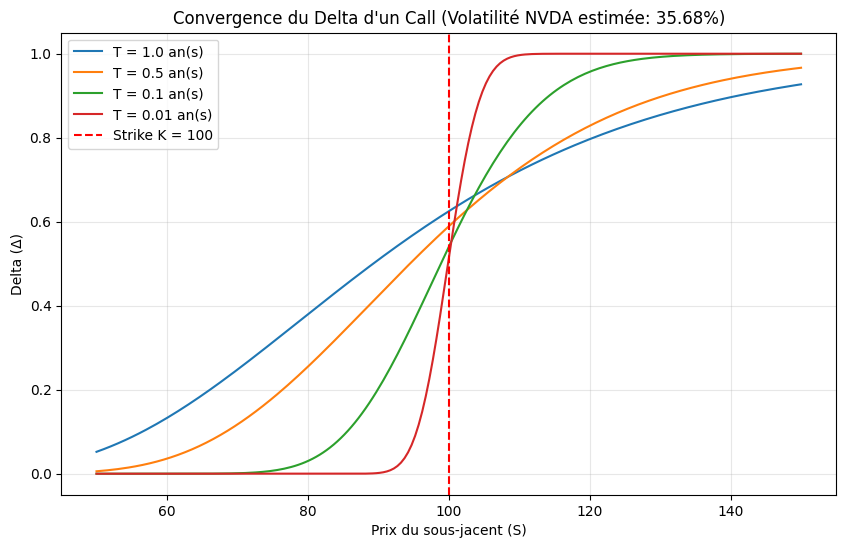

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

# 1. Moteur de Pricing & Grecs
def bs_params(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return d1, d2

def calculate_delta(S, K, T, r, sigma, option_type="call"):
    d1, _ = bs_params(S, K, T, r, sigma)
    if option_type.lower() == "call":
        return norm.cdf(d1)
    elif option_type.lower() == "put":
        return norm.cdf(d1) - 1
    raise ValueError("option_type doit être 'call' ou 'put'")

# 2. Estimation et Graphique
def estimate_historical_volatility(ticker, period="1y"):
    print(f"Récupération des données pour {ticker}...")
    # On force yfinance à renvoyer un DataFrame simple sans MultiIndex complexe
    data = yf.download(ticker, period=period, group_by='column')

    # On cherche la colonne Close ou Adj Close de manière robuste
    if 'Adj Close' in data.columns:
        close_prices = data['Adj Close']
    elif 'Close' in data.columns:
        close_prices = data['Close']
    else:
        # Si yfinance a quand même fait un MultiIndex
        close_prices = data.xs('Adj Close', axis=1, level=0) if 'Adj Close' in data.columns.levels[0] else data.xs('Close', axis=1, level=0)

    # Calcul des log-rendements
    log_returns = np.log(close_prices / close_prices.shift(1)).dropna()

    # Volatilité annualisée
    annualized_vol = np.std(log_returns.values) * np.sqrt(252)
    return float(annualized_vol)

def generate_delta_chart(sigma, ticker):
    S_range = np.linspace(50, 150, 200)
    K = 100
    r = 0.05
    times_to_expiry = [1.0, 0.5, 0.1, 0.01]

    plt.figure(figsize=(10, 6))
    for T in times_to_expiry:
        deltas = [calculate_delta(S, K, T, r, sigma, "call") for S in S_range]
        plt.plot(S_range, deltas, label=f"T = {T} an(s)")

    plt.axvline(x=K, color="red", linestyle="--", label=f"Strike K = {K}")
    plt.title(f"Convergence du Delta d'un Call (Volatilité {ticker} estimée: {sigma:.2%})")
    plt.xlabel("Prix du sous-jacent (S)")
    plt.ylabel("Delta (Δ)")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Sauvegarde locale sur l'espace Colab
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/delta_convergence.png", dpi=300)
    plt.show()

# Exécution
ticker = "NVDA"
try:
    vol = estimate_historical_volatility(ticker)
    print(f"Volatilité historique estimée pour {ticker} : {vol:.2%}")
    generate_delta_chart(vol, ticker)
except Exception as e:
    print(f"Erreur : {e}")
    generate_delta_chart(0.25, "Default")